# Domain - Health Care

# Task - Binary-Class Classification

## Project Code-PRCP-1016-HeartDieseasePred
### Project Name- Heart Disease Prediction
### Data Description - The dataset is an excerpt from a study of heart disease which contains various measurements on patient health and cardiovascular statistics. The target is to predict if a patient has any cardiovascular disease or not.

In [1]:
# importing basic libraries for dataframe manupilation / visulization / mathematical-scientificle calculations

import pandas as pd # for dataframe loading and manupilation
import numpy as np # for numeric calculations
import seaborn as sns # for data visulization
import matplotlib.pyplot as plt # for plotting and redering graphs
import warnings
warnings.filterwarnings('ignore')

In [2]:
# loading two dataframes in two different variables because we have two csv files for this project

df1 = pd.read_csv('labels.csv') # df1 consist one mutual column(patient_id) and other is our output column(heart_disease_present) 
df2 = pd.read_csv('values.csv') # df2 consist other input features

In [3]:
df1 # calling dataframe 1

,patient_id,heart_disease_present
0,0z64un,0
1,ryoo3j,0
2,yt1s1x,1
3,l2xjde,1
4,oyt4ek,0
...,...,...
175,5qfar3,1
176,2s2b1f,1
177,nsd00i,1
178,0xw93k,0


In [4]:
df2 # calling dataframe 2

,patient_id,slope_of_peak_exercise_st_segment,thal,resting_blood_pressure,chest_pain_type,num_major_vessels,fasting_blood_sugar_gt_120_mg_per_dl,resting_ekg_results,serum_cholesterol_mg_per_dl,oldpeak_eq_st_depression,sex,age,max_heart_rate_achieved,exercise_induced_angina
0,0z64un,1,normal,128,2,0,0,2,308,0.0,1,45,170,0
1,ryoo3j,2,normal,110,3,0,0,0,214,1.6,0,54,158,0
2,yt1s1x,1,normal,125,4,3,0,2,304,0.0,1,77,162,1
3,l2xjde,1,reversible_defect,152,4,0,0,0,223,0.0,1,40,181,0
4,oyt4ek,3,reversible_defect,178,1,0,0,2,270,4.2,1,59,145,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
175,5qfar3,2,reversible_defect,125,4,2,1,0,254,0.2,1,67,163,0
176,2s2b1f,2,normal,180,4,0,0,1,327,3.4,0,55,117,1
177,nsd00i,2,reversible_defect,125,3,0,0,0,309,1.8,1,64,131,1
178,0xw93k,1,normal,124,3,2,1,0,255,0.0,1,48,175,0


# Domain Analysis

In [5]:
# .column- to print all the columns of dataframe

df1.columns

Index(['patient_id', 'heart_disease_present'], dtype='object')

In [6]:
df2.columns

Index(['patient_id', 'slope_of_peak_exercise_st_segment', 'thal',
       'resting_blood_pressure', 'chest_pain_type', 'num_major_vessels',
       'fasting_blood_sugar_gt_120_mg_per_dl', 'resting_ekg_results',
       'serum_cholesterol_mg_per_dl', 'oldpeak_eq_st_depression', 'sex', 'age',
       'max_heart_rate_achieved', 'exercise_induced_angina'],
      dtype='object')

# Basic Check

(from merged dataframe)

### Combining Two DataFrames for Basic Checks and Further Operations :


In [7]:
# left-defining left table , right- defining right table , on-mutual column  how-type of join

merged_df = pd.merge(left=df1 , right=df2 , on='patient_id' , how='inner')

merged_df #final data fram for the project

,patient_id,heart_disease_present,slope_of_peak_exercise_st_segment,thal,resting_blood_pressure,chest_pain_type,num_major_vessels,fasting_blood_sugar_gt_120_mg_per_dl,resting_ekg_results,serum_cholesterol_mg_per_dl,oldpeak_eq_st_depression,sex,age,max_heart_rate_achieved,exercise_induced_angina
0,0z64un,0,1,normal,128,2,0,0,2,308,0.0,1,45,170,0
1,ryoo3j,0,2,normal,110,3,0,0,0,214,1.6,0,54,158,0
2,yt1s1x,1,1,normal,125,4,3,0,2,304,0.0,1,77,162,1
3,l2xjde,1,1,reversible_defect,152,4,0,0,0,223,0.0,1,40,181,0
4,oyt4ek,0,3,reversible_defect,178,1,0,0,2,270,4.2,1,59,145,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
175,5qfar3,1,2,reversible_defect,125,4,2,1,0,254,0.2,1,67,163,0
176,2s2b1f,1,2,normal,180,4,0,0,1,327,3.4,0,55,117,1
177,nsd00i,1,2,reversible_defect,125,3,0,0,0,309,1.8,1,64,131,1
178,0xw93k,0,1,normal,124,3,2,1,0,255,0.0,1,48,175,0


In [8]:
merged_df.info()  # .info() - gives information like indices , non-null count , dtype about all features

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 180 entries, 0 to 179
Data columns (total 15 columns):
 #   Column                                Non-Null Count  Dtype  
---  ------                                --------------  -----  
 0   patient_id                            180 non-null    object 
 1   heart_disease_present                 180 non-null    int64  
 2   slope_of_peak_exercise_st_segment     180 non-null    int64  
 3   thal                                  180 non-null    object 
 4   resting_blood_pressure                180 non-null    int64  
 5   chest_pain_type                       180 non-null    int64  
 6   num_major_vessels                     180 non-null    int64  
 7   fasting_blood_sugar_gt_120_mg_per_dl  180 non-null    int64  
 8   resting_ekg_results                   180 non-null    int64  
 9   serum_cholesterol_mg_per_dl           180 non-null    int64  
 10  oldpeak_eq_st_depression              180 non-null    float64
 11  sex                

In [9]:
merged_df.describe() # .describe() - describes statistical information about numeric features

,heart_disease_present,slope_of_peak_exercise_st_segment,resting_blood_pressure,chest_pain_type,num_major_vessels,fasting_blood_sugar_gt_120_mg_per_dl,resting_ekg_results,serum_cholesterol_mg_per_dl,oldpeak_eq_st_depression,sex,age,max_heart_rate_achieved,exercise_induced_angina
count,180.000000,180.000000,180.000000,180.000000,180.000000,180.000000,180.000000,180.000000,180.000000,180.000000,180.000000,180.000000,180.000000
mean,0.444444,1.550000,131.311111,3.155556,0.694444,0.161111,1.050000,249.211111,1.010000,0.688889,54.811111,149.483333,0.316667
std,0.498290,0.618838,17.010443,0.938454,0.969347,0.368659,0.998742,52.717969,1.121357,0.464239,9.334737,22.063513,0.466474
min,0.000000,1.000000,94.000000,1.000000,0.000000,0.000000,0.000000,126.000000,0.000000,0.000000,29.000000,96.000000,0.000000
25%,0.000000,1.000000,120.000000,3.000000,0.000000,0.000000,0.000000,213.750000,0.000000,0.000000,48.000000,132.000000,0.000000
50%,0.000000,1.000000,130.000000,3.000000,0.000000,0.000000,2.000000,245.500000,0.800000,1.000000,55.000000,152.000000,0.000000
75%,1.000000,2.000000,140.000000,4.000000,1.000000,0.000000,2.000000,281.250000,1.600000,1.000000,62.000000,166.250000,1.000000
max,1.000000,3.000000,180.000000,4.000000,3.000000,1.000000,2.000000,564.000000,6.200000,1.000000,77.000000,202.000000,1.000000


In [10]:
# running up a loop through the dataframe to print all the unique values of each columns with .unique() attribute.

for i in merged_df:
    print(i,merged_df[i].unique())

patient_id ['0z64un' 'ryoo3j' 'yt1s1x' 'l2xjde' 'oyt4ek' 'ldukkw' '2gbyh9' 'daa9kp'
 '3nwy2n' '1r508r' 'ldg4b9' 'xc17yq' 'mpggsq' 'zlyac8' 'f06u72' '2fv3rc'
 'qyrkxn' '237mql' 'mc750a' '30v796' 'cvux3j' 'k8899q' 'jhdvtb' '5g9v0h'
 '83asqd' 'gla0im' 'zzmfh7' 'f4g1ay' 'lek9q9' '8265rl' '6017a1' 'z7xkou'
 'k7ef7h' '0n5fu0' '55xksg' 'pjgqa3' 'xkdz7j' 'tpuevg' 'ascl42' '1xwoe6'
 'ty4ik8' 'gx6yxl' 'hlmts5' 'yx0q6k' 'ep1o51' 'gj1e5z' '6219kl' 'rp9g6x'
 '1aeaff' 'y3prof' '3drd48' 'ejo7p3' 'r7y4i1' 'mznwxv' '27oevk' 'jwqi3k'
 '328lkl' 'tlk9o8' 'aq2vrq' 'ilogfb' 'rv6siv' 'm2a4i9' 'pwigd8' 'qwapdq'
 '4sd1xn' 'nck22c' 'm6zksp' 'f70grj' 'k1art8' 'mcwqgs' '3jsjqk' 'ik7hfs'
 'qwj1yf' 'qvhk9e' 'igwnqo' '4v0q7o' 'hh2awp' 'vfjppl' '6lu42b' 'shiro4'
 '3wl3z4' 'ebioez' '37c0vm' 'v52zcs' '6nkcaw' 'hfp05i' 'grfxwd' 'bvcxah'
 'i49srr' '93dbhq' 'jscmp8' 'zaytyf' 'wze8qm' 'w3933i' '7uch9x' 'dy5hxt'
 'c0gkqc' 'z5g5p3' 'h3uzv8' 'bthqr4' 'rfj25e' '9f92et' '24fopx' 'ldr1mz'
 'wokyol' 'p5orwa' 's8dx1q' '7kf275' 'e6

# EDA - Exploratory Data Analysis

## Univariate Data Analysis

In [11]:
# creating a dataframe for EDA(to exclude patient_column since , The patient_id column contains all unique values.)

df_for_eda = merged_df.drop('patient_id' , axis=1) 

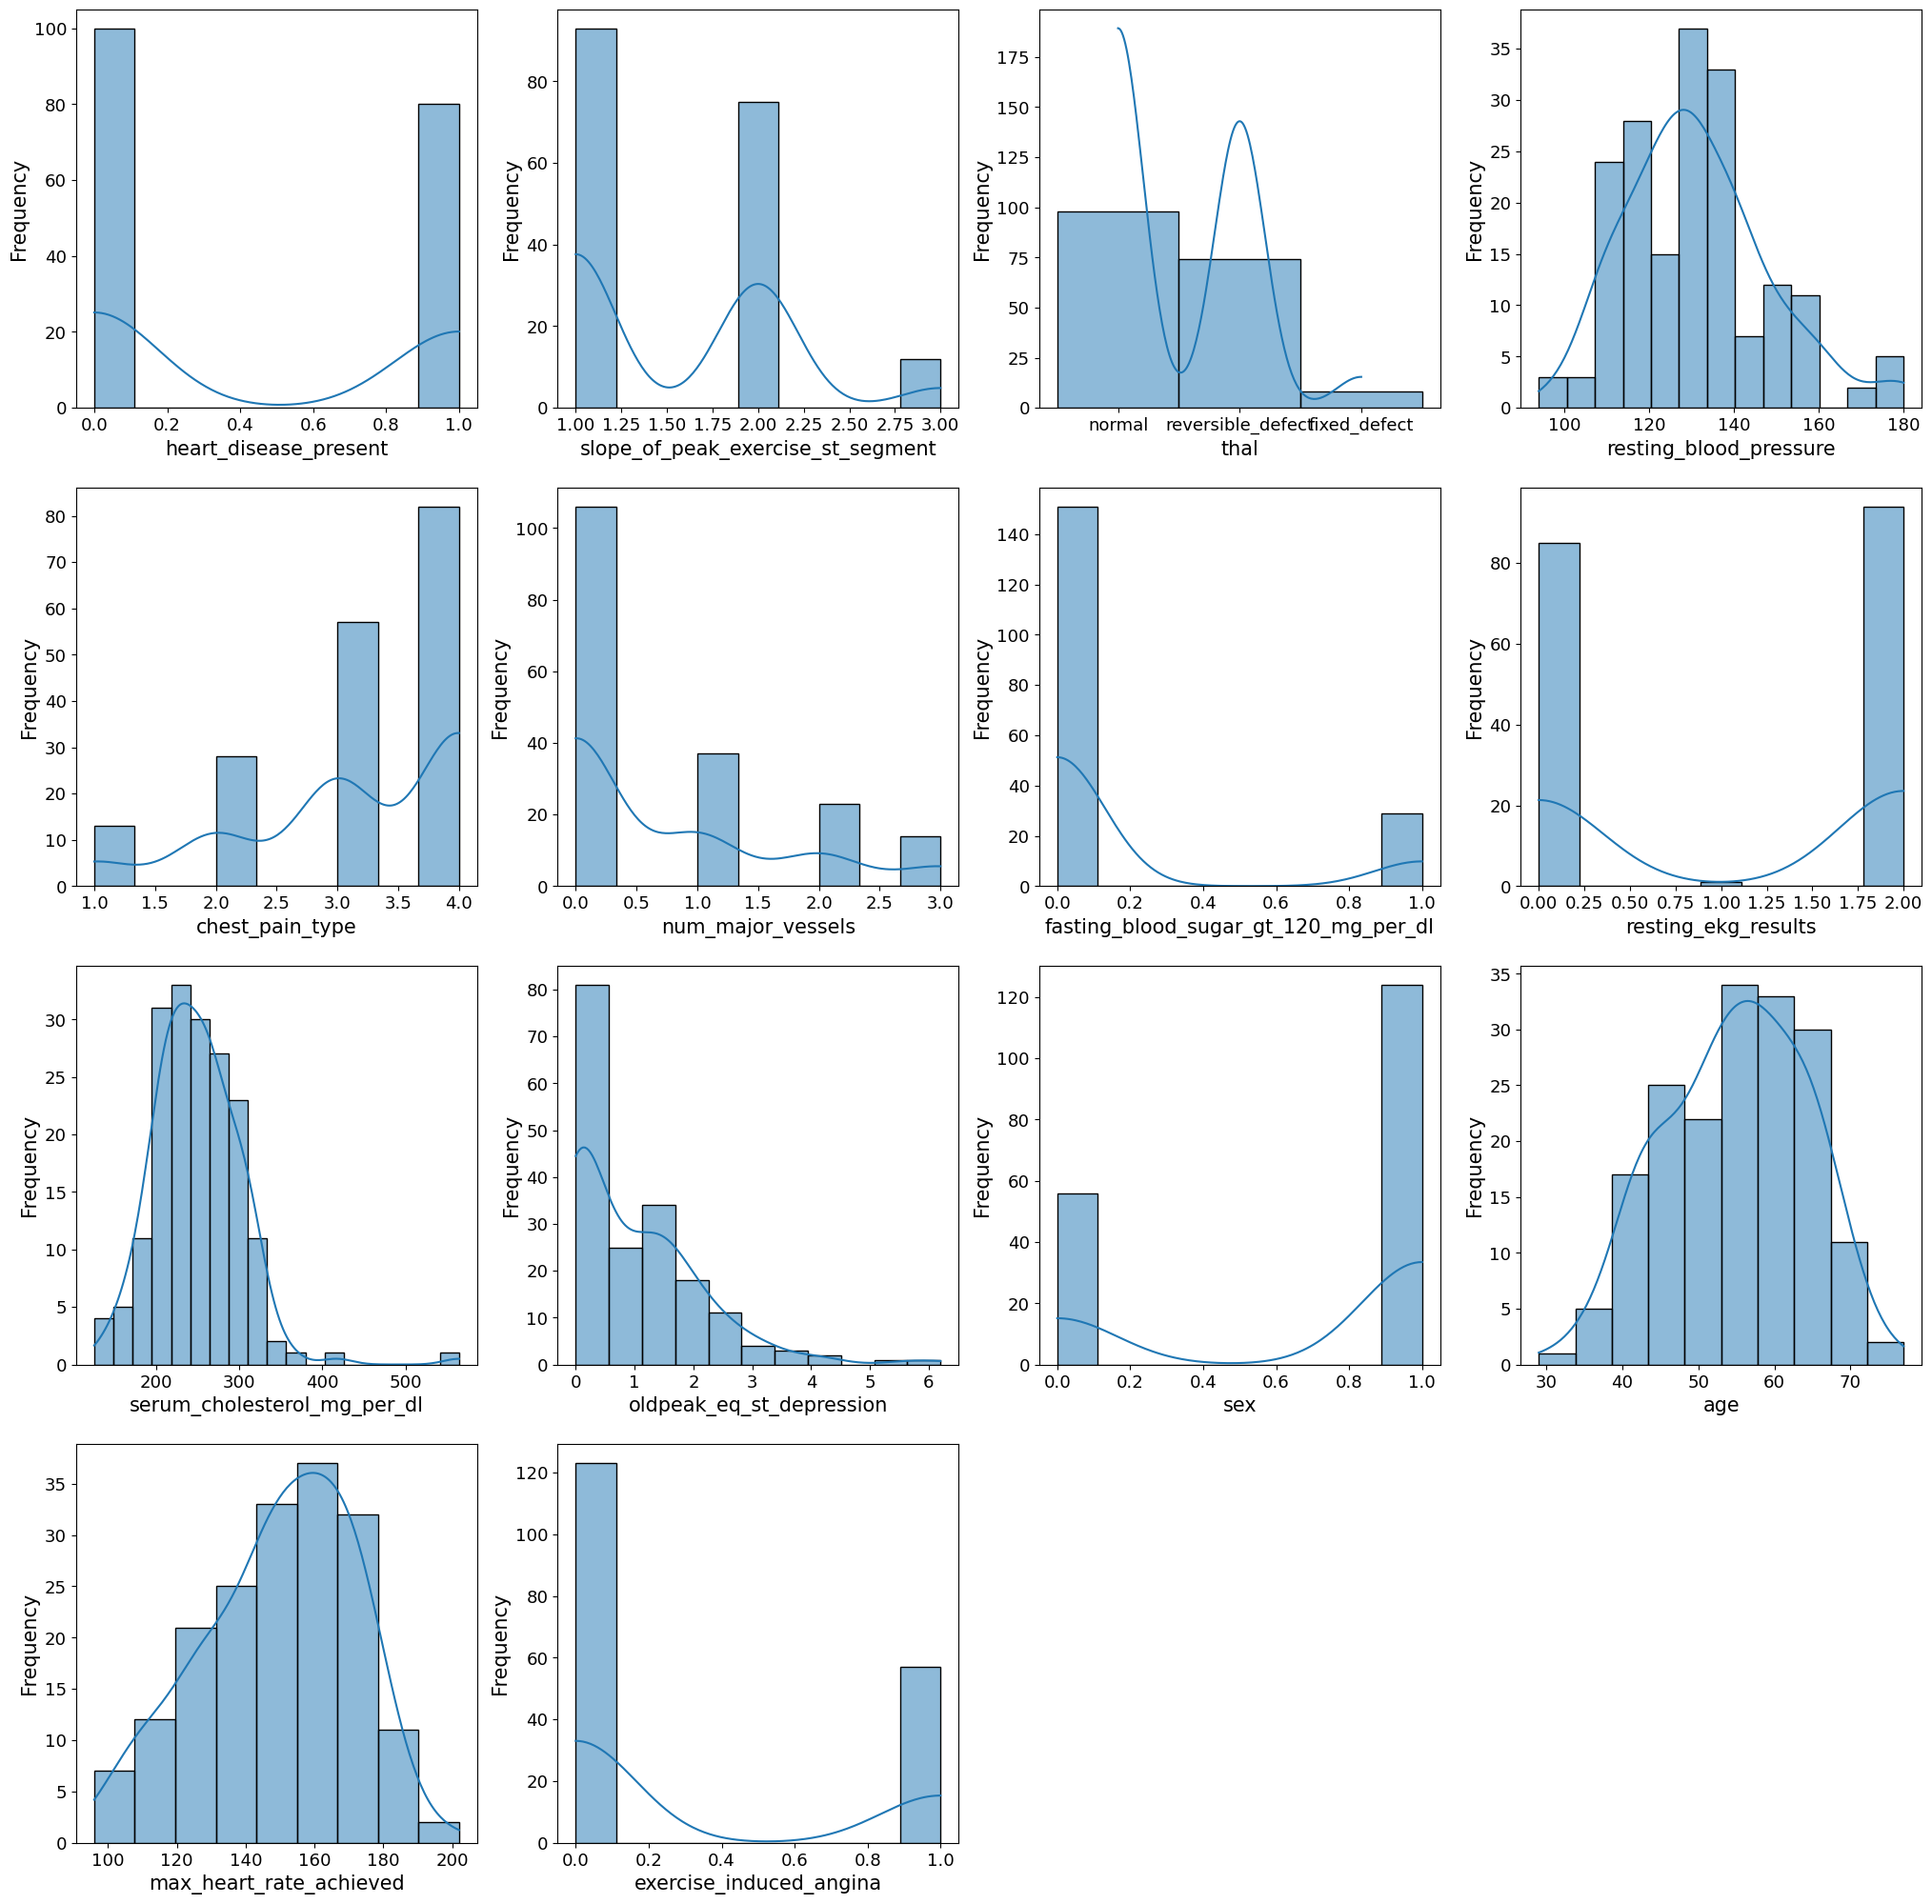

<Figure size 640x480 with 0 Axes>

In [12]:
plt.figure(figsize=(25,25))
subplot_ind=1  # defining indices for sub-plot allocation

for i in df_for_eda: # iterating through created dataframe for eda 
    if subplot_ind <=14:
        plt.subplot(4,4 , subplot_ind)  # 4 - represents rows of subplot , 4 - represents columns subplot
        sns.histplot(df_for_eda[i] , kde=True) # plotting hist-plots through a loop variable
        plt.xlabel(i , fontsize=15)
        plt.ylabel('Frequency', fontsize=15)
        plt.xticks(fontsize=13)
        plt.yticks(fontsize=13)
        subplot_ind+=1 # incrementing loop variable to iterate through a dataframe
plt.show()
plt.tight_layout()

### Insights From Univariate Data Analysis

## BiVariate Data Analysis

In [13]:
numerical_features = [
    'resting_blood_pressure', 'chest_pain_type', 'num_major_vessels',
    'fasting_blood_sugar_gt_120_mg_per_dl', 'resting_ekg_results',
    'serum_cholesterol_mg_per_dl', 'oldpeak_eq_st_depression', 'sex', 'age',
    'max_heart_rate_achieved', 'exercise_induced_angina'
]

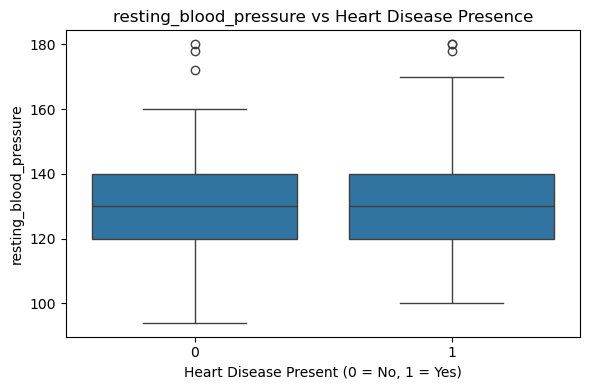

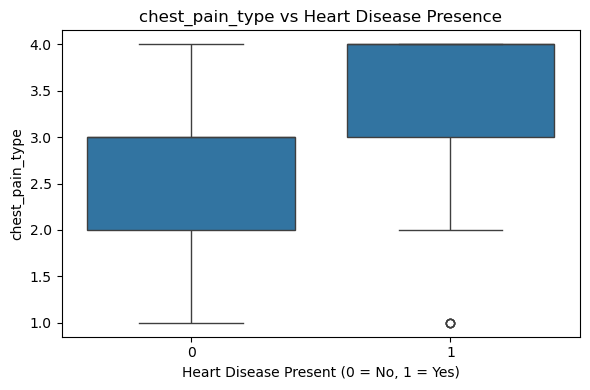

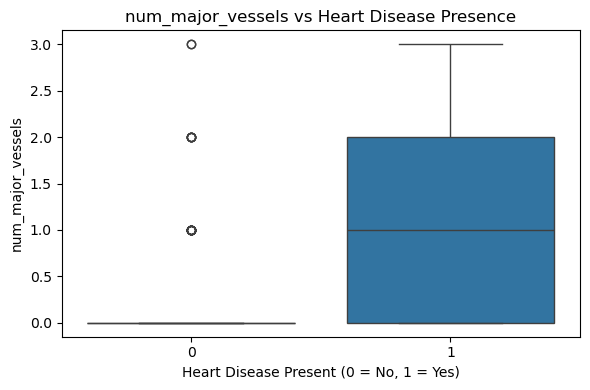

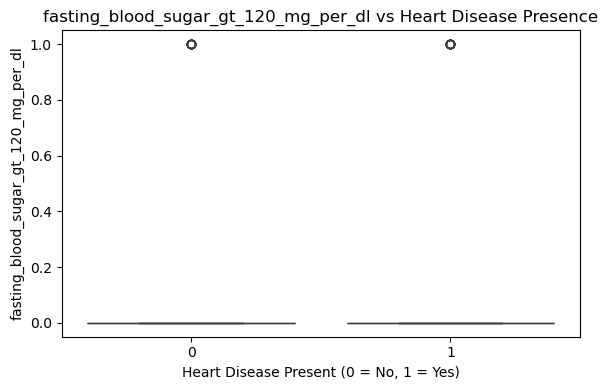

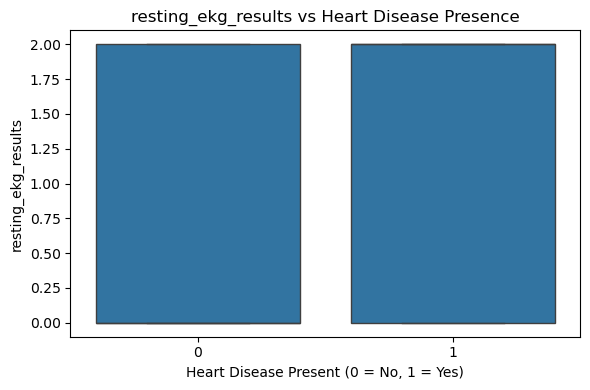

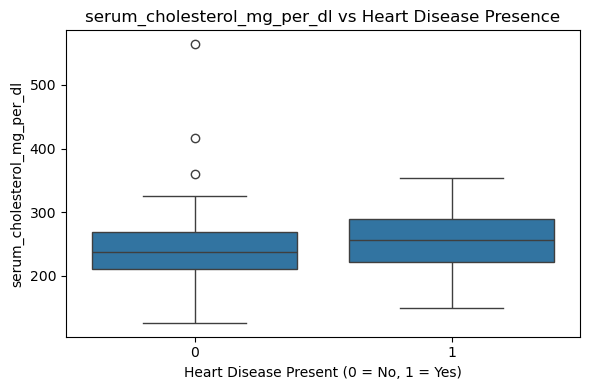

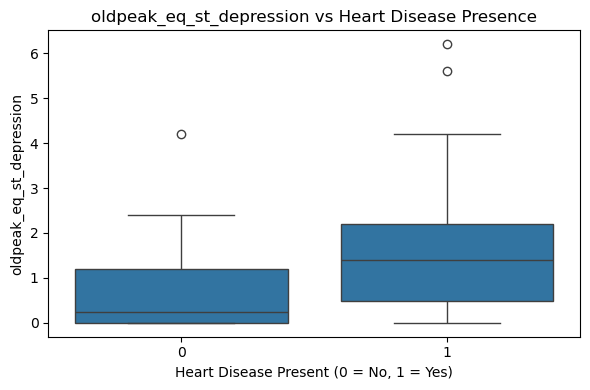

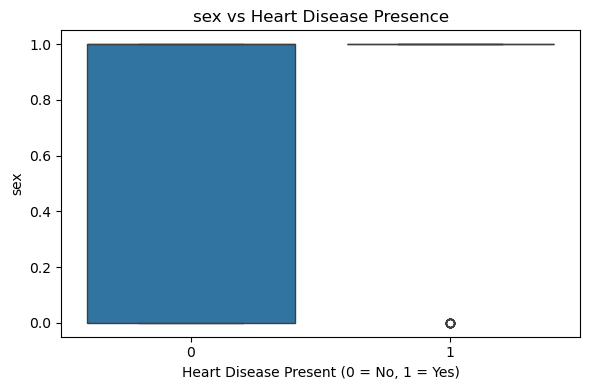

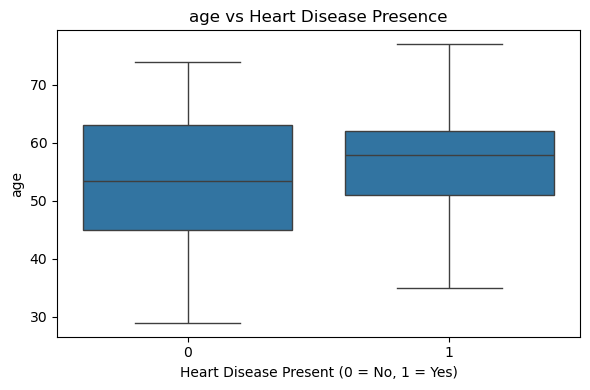

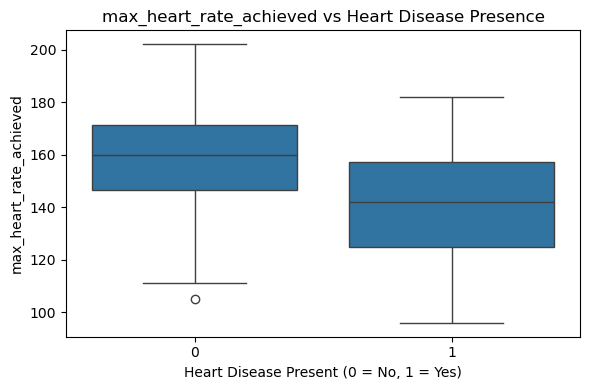

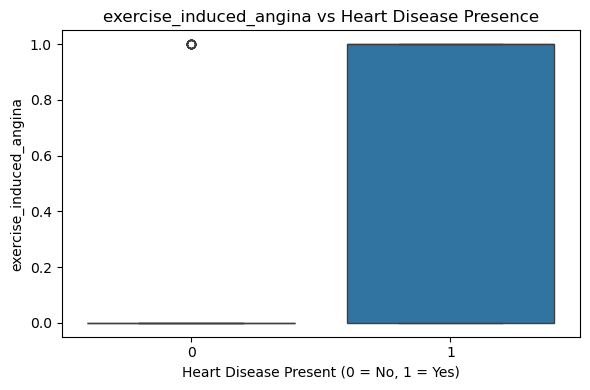

In [14]:
for col in numerical_features:
    plt.figure(figsize=(6, 4))
    sns.boxplot(x='heart_disease_present', y=col, data=merged_df)
    plt.title(f'{col} vs Heart Disease Presence')
    plt.xlabel('Heart Disease Present (0 = No, 1 = Yes)')
    plt.ylabel(col)
    plt.tight_layout()
    plt.show()

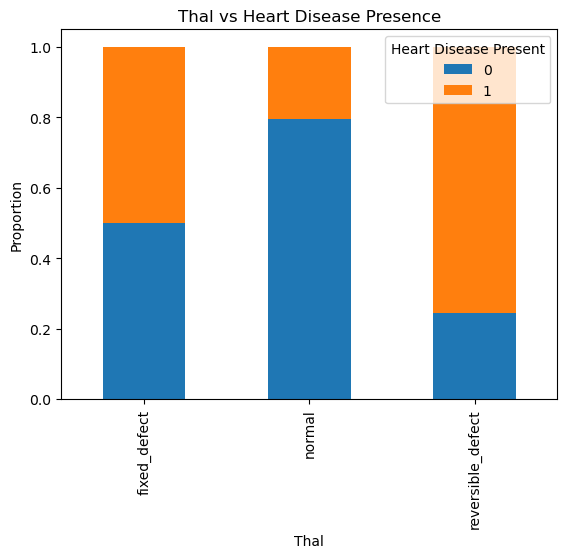

In [15]:
pd.crosstab(merged_df['thal'], merged_df['heart_disease_present'], normalize='index').plot(kind='bar', stacked=True)
plt.title('Thal vs Heart Disease Presence')
plt.ylabel('Proportion')
plt.xlabel('Thal')
plt.legend(title='Heart Disease Present')
plt.show()

### Insights From Bi-Univariate Data Analysis

# Feature Engineering

##  Data Pre-Processing

### Encoding Task

with one-hot encoding

In [16]:
# creating dummy variables to for thal column

dummy_thal = pd.get_dummies(merged_df['thal'] , dtype='int')

In [17]:
dummy_thal # calling dummy vairable to review

,fixed_defect,normal,reversible_defect
0,0,1,0
1,0,1,0
2,0,1,0
3,0,0,1
4,0,0,1
...,...,...,...
175,0,0,1
176,0,1,0
177,0,0,1
178,0,1,0


In [18]:
# concatinating encoded dataframe with main dataframe

merged_df = pd.concat((merged_df , dummy_thal) , axis=1)

In [19]:
merged_df.drop('thal' , axis=1 , inplace=True) #dropping old thal features since it's now encoded

merged_df

,patient_id,heart_disease_present,slope_of_peak_exercise_st_segment,resting_blood_pressure,chest_pain_type,num_major_vessels,fasting_blood_sugar_gt_120_mg_per_dl,resting_ekg_results,serum_cholesterol_mg_per_dl,oldpeak_eq_st_depression,sex,age,max_heart_rate_achieved,exercise_induced_angina,fixed_defect,normal,reversible_defect
0,0z64un,0,1,128,2,0,0,2,308,0.0,1,45,170,0,0,1,0
1,ryoo3j,0,2,110,3,0,0,0,214,1.6,0,54,158,0,0,1,0
2,yt1s1x,1,1,125,4,3,0,2,304,0.0,1,77,162,1,0,1,0
3,l2xjde,1,1,152,4,0,0,0,223,0.0,1,40,181,0,0,0,1
4,oyt4ek,0,3,178,1,0,0,2,270,4.2,1,59,145,0,0,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
175,5qfar3,1,2,125,4,2,1,0,254,0.2,1,67,163,0,0,0,1
176,2s2b1f,1,2,180,4,0,0,1,327,3.4,0,55,117,1,0,1,0
177,nsd00i,1,2,125,3,0,0,0,309,1.8,1,64,131,1,0,0,1
178,0xw93k,0,1,124,3,2,1,0,255,0.0,1,48,175,0,0,1,0


### Outliers Handling In Continuous Features

1] resting_blood_pressure

2]serum_cholesterol_mg_per_dl

3]oldpeak_eq_st_depression

4]age

5]max_heart_rate_achieved

<Axes: xlabel='resting_blood_pressure'>

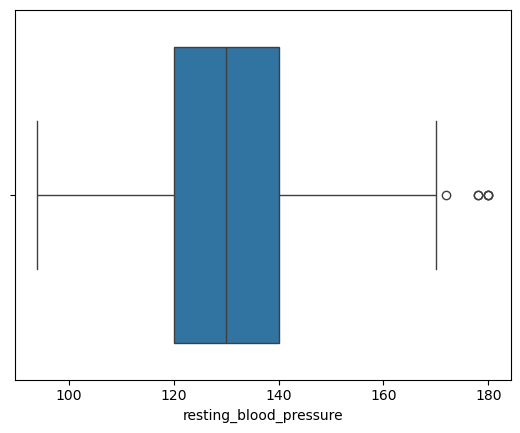

In [20]:
# plotting boxplot for resting_blood_pressure

sns.boxplot(x=merged_df['resting_blood_pressure'])

In [21]:
# finding lower and upper bound

q1_resting_blood_pressure=120.000000
q3_resting_blood_pressure=140.000000	

iqr_resting_blood_pressure= q3_resting_blood_pressure-q1_resting_blood_pressure

lb_resting_blood_pressure= q1_resting_blood_pressure - iqr_resting_blood_pressure *1.5
ub_resting_blood_pressure= q3_resting_blood_pressure + iqr_resting_blood_pressure *1.5

print('l.b=',lb_resting_blood_pressure)
print('u.b=',ub_resting_blood_pressure)

l.b= 90.0
u.b= 170.0


In [22]:
# handled outliers in resting_blood_pressure

merged_df.loc[merged_df['resting_blood_pressure']>170  , 'resting_blood_pressure'] = 130

<Axes: xlabel='serum_cholesterol_mg_per_dl'>

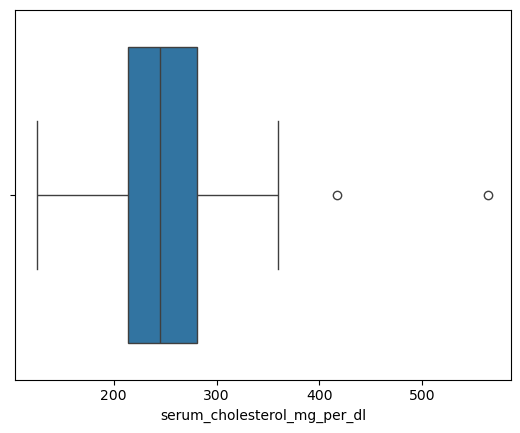

In [23]:
# plotting boxplot for serum_cholesterol_mg_per_dl

sns.boxplot(x=merged_df['serum_cholesterol_mg_per_dl'])

In [24]:
# finding lower and upper bound

q1_serum_cholesterol_mg_per_dl=213.750000
q3_serum_cholesterol_mg_per_dl=281.250000

iqr_serum_cholesterol_mg_per_dl= q3_serum_cholesterol_mg_per_dl-q1_serum_cholesterol_mg_per_dl

lb_serum_cholesterol_mg_per_dl= q1_serum_cholesterol_mg_per_dl - iqr_serum_cholesterol_mg_per_dl *1.5
ub_serum_cholesterol_mg_per_dl= q3_serum_cholesterol_mg_per_dl + iqr_serum_cholesterol_mg_per_dl *1.5

print('l.b=',lb_serum_cholesterol_mg_per_dl)
print('u.b=',ub_serum_cholesterol_mg_per_dl)

l.b= 112.5
u.b= 382.5


In [25]:
# handled outliers in resting_blood_pressure

merged_df.loc[merged_df['serum_cholesterol_mg_per_dl']>382  , 'serum_cholesterol_mg_per_dl'] = 245

<Axes: xlabel='oldpeak_eq_st_depression'>

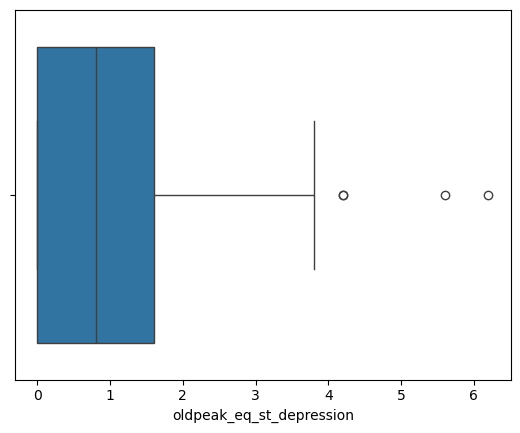

In [26]:
# plotting boxplot for oldpeak_eq_st_depression

sns.boxplot(x=merged_df['oldpeak_eq_st_depression'])

In [27]:
# finding lower and upper bound

q1_oldpeak_eq_st_depression=0.000000
q3_oldpeak_eq_st_depression=1.600000

iqr_oldpeak_eq_st_depression= q3_oldpeak_eq_st_depression-q1_oldpeak_eq_st_depression

lb_oldpeak_eq_st_depression= q1_oldpeak_eq_st_depression - iqr_oldpeak_eq_st_depression *1.5
ub_oldpeak_eq_st_depression= q3_oldpeak_eq_st_depression + iqr_oldpeak_eq_st_depression *1.5

print('l.b=',lb_oldpeak_eq_st_depression)
print('u.b=',ub_oldpeak_eq_st_depression)

l.b= -2.4000000000000004
u.b= 4.0


In [28]:
# handling outliers in oldpeak_eq_st_depression column

merged_df.loc[merged_df['oldpeak_eq_st_depression']>4 , 'oldpeak_eq_st_depression'] = 0.800000

<Axes: xlabel='age'>

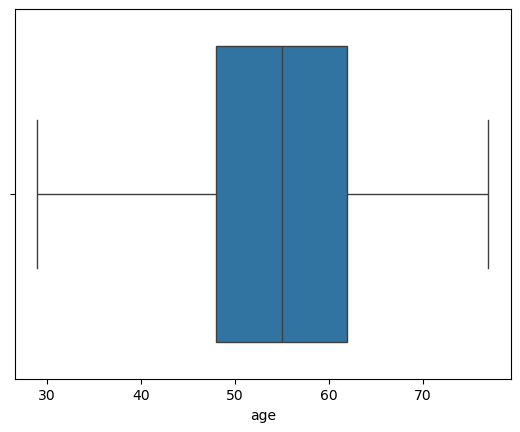

In [29]:
# plotting boxplot for age

sns.boxplot(x=merged_df['age'])

#### no outliers found in age column

In [30]:
# plotting boxplot for max_heart_rate_achieved

<Axes: xlabel='max_heart_rate_achieved'>

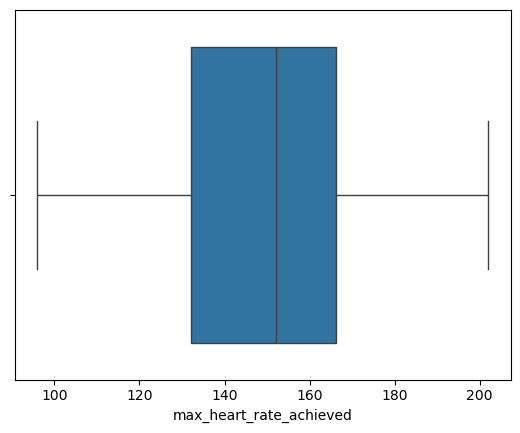

In [31]:
sns.boxplot(x=merged_df['max_heart_rate_achieved'])

#### no outliers found in age column

## importing min-max scaler

In [32]:
from sklearn.preprocessing import MinMaxScaler
min_max=MinMaxScaler()
min_max

MinMaxScaler()

In [33]:
# scaling out continuous five features

merged_df[['resting_blood_pressure','serum_cholesterol_mg_per_dl','oldpeak_eq_st_depression','age','max_heart_rate_achieved']] = min_max.fit_transform(merged_df[['resting_blood_pressure','serum_cholesterol_mg_per_dl','oldpeak_eq_st_depression','age','max_heart_rate_achieved']])

In [34]:
# calling final daraframe

merged_df

,patient_id,heart_disease_present,slope_of_peak_exercise_st_segment,resting_blood_pressure,chest_pain_type,num_major_vessels,fasting_blood_sugar_gt_120_mg_per_dl,resting_ekg_results,serum_cholesterol_mg_per_dl,oldpeak_eq_st_depression,sex,age,max_heart_rate_achieved,exercise_induced_angina,fixed_defect,normal,reversible_defect
0,0z64un,0,1,0.447368,2,0,0,2,0.777778,0.000000,1,0.333333,0.698113,0,0,1,0
1,ryoo3j,0,2,0.210526,3,0,0,0,0.376068,0.421053,0,0.520833,0.584906,0,0,1,0
2,yt1s1x,1,1,0.407895,4,3,0,2,0.760684,0.000000,1,1.000000,0.622642,1,0,1,0
3,l2xjde,1,1,0.763158,4,0,0,0,0.414530,0.000000,1,0.229167,0.801887,0,0,0,1
4,oyt4ek,0,3,0.473684,1,0,0,2,0.615385,0.210526,1,0.625000,0.462264,0,0,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
175,5qfar3,1,2,0.407895,4,2,1,0,0.547009,0.052632,1,0.791667,0.632075,0,0,0,1
176,2s2b1f,1,2,0.473684,4,0,0,1,0.858974,0.894737,0,0.541667,0.198113,1,0,1,0
177,nsd00i,1,2,0.407895,3,0,0,0,0.782051,0.473684,1,0.729167,0.330189,1,0,0,1
178,0xw93k,0,1,0.394737,3,2,1,0,0.551282,0.000000,1,0.395833,0.745283,0,0,1,0


# Feature Selection

Use-ful insights from heatmap:

1]We will drop patient_id since it behaves like a primary key (a unique identifier for each row).

2]The correlation of fasting_blood_sugar_gt_120_mg_per_dl with the target is 0.0034, which is nearly zero. Therefore, it is safe to drop this feature for most models.

3]No other input features are highly correlated with each other or with the target, so we will retain the remaining features for model training.

<Axes: >

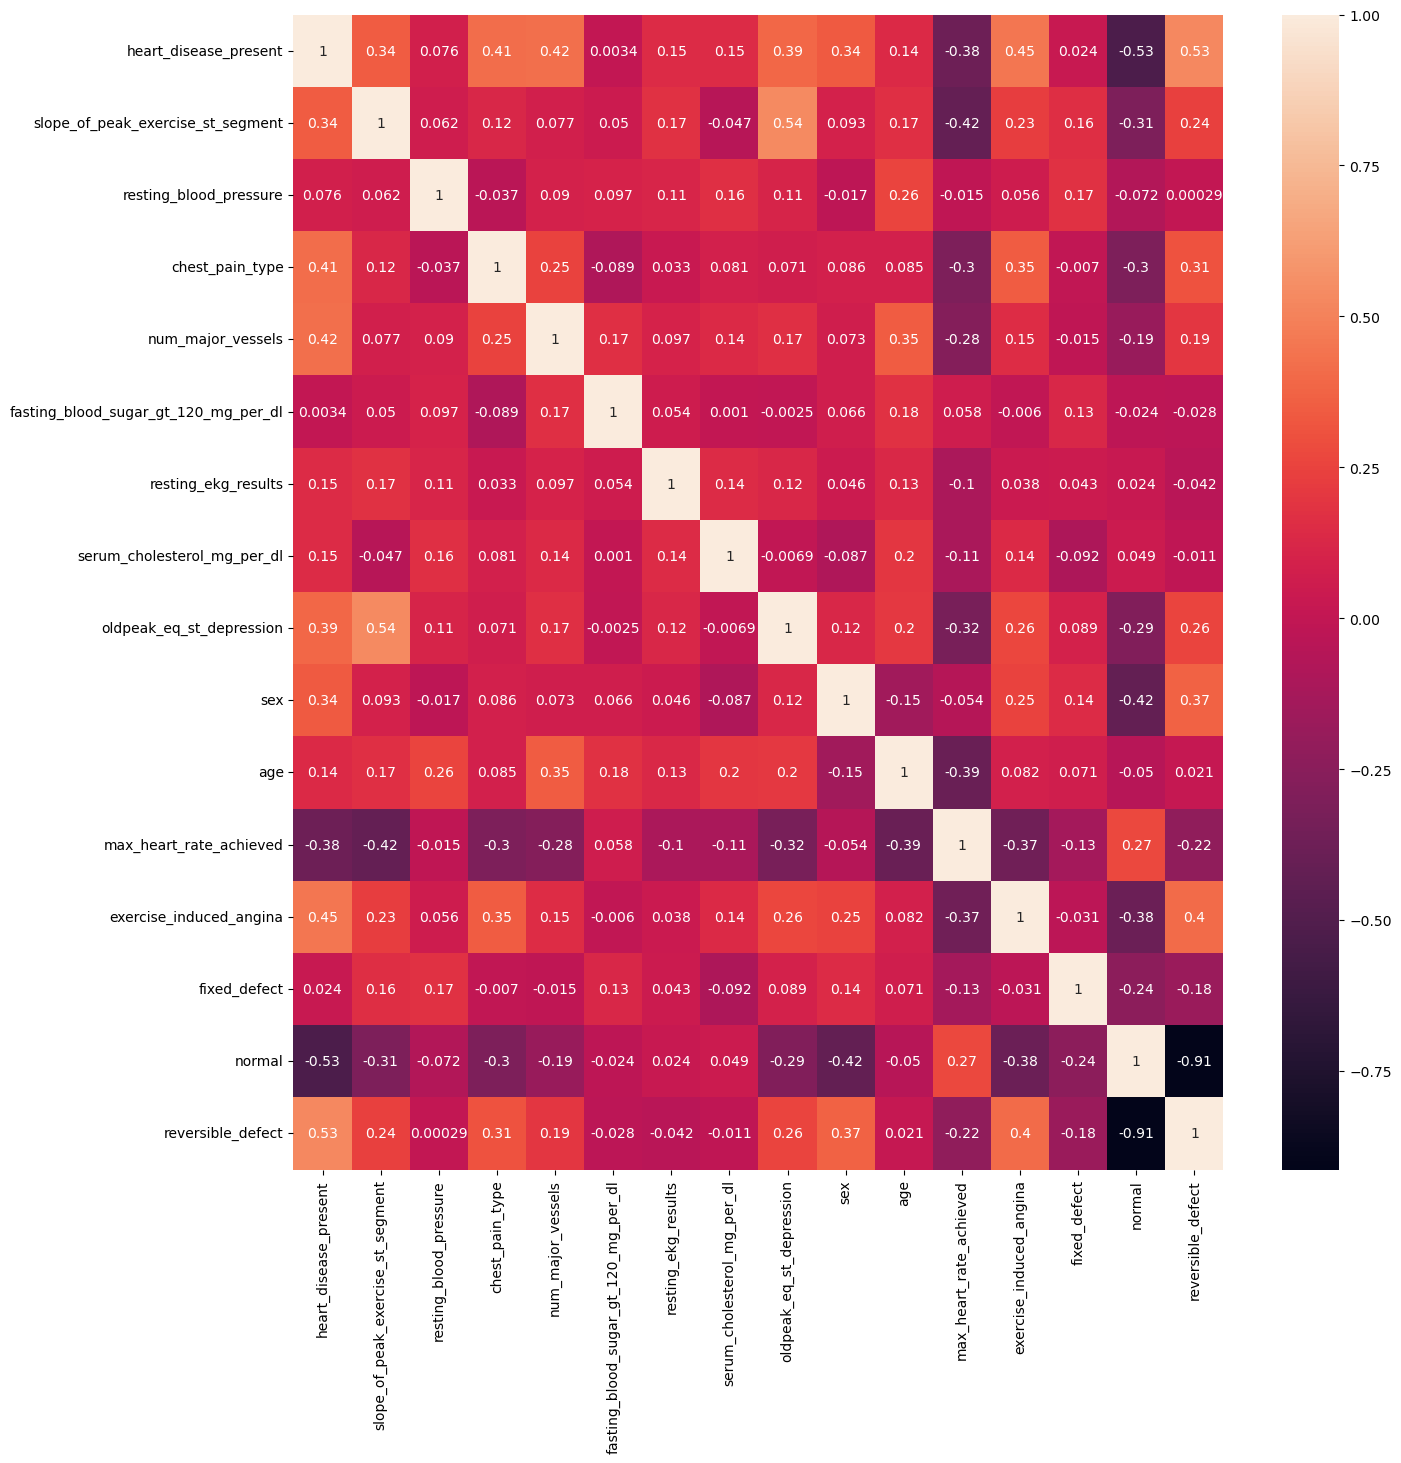

In [35]:
# plotting heatmap to find co-relation 

plt.figure(figsize=(15,15))
sns.heatmap(merged_df.corr(numeric_only=True) , annot=True)

In [36]:
#dropping less co-related feature 

merged_df.drop(['fasting_blood_sugar_gt_120_mg_per_dl', 'patient_id'] , axis=1 , inplace=True)

#### Final  DataFrame

In [37]:
merged_df

,heart_disease_present,slope_of_peak_exercise_st_segment,resting_blood_pressure,chest_pain_type,num_major_vessels,resting_ekg_results,serum_cholesterol_mg_per_dl,oldpeak_eq_st_depression,sex,age,max_heart_rate_achieved,exercise_induced_angina,fixed_defect,normal,reversible_defect
0,0,1,0.447368,2,0,2,0.777778,0.000000,1,0.333333,0.698113,0,0,1,0
1,0,2,0.210526,3,0,0,0.376068,0.421053,0,0.520833,0.584906,0,0,1,0
2,1,1,0.407895,4,3,2,0.760684,0.000000,1,1.000000,0.622642,1,0,1,0
3,1,1,0.763158,4,0,0,0.414530,0.000000,1,0.229167,0.801887,0,0,0,1
4,0,3,0.473684,1,0,2,0.615385,0.210526,1,0.625000,0.462264,0,0,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
175,1,2,0.407895,4,2,0,0.547009,0.052632,1,0.791667,0.632075,0,0,0,1
176,1,2,0.473684,4,0,1,0.858974,0.894737,0,0.541667,0.198113,1,0,1,0
177,1,2,0.407895,3,0,0,0.782051,0.473684,1,0.729167,0.330189,1,0,0,1
178,0,1,0.394737,3,2,0,0.551282,0.000000,1,0.395833,0.745283,0,0,1,0


# Model Creation

In [38]:
# creating input-output variable for model and data balancing

input_features=merged_df[['slope_of_peak_exercise_st_segment',
       'resting_blood_pressure', 'chest_pain_type', 'num_major_vessels',
       'resting_ekg_results', 'serum_cholesterol_mg_per_dl',
       'oldpeak_eq_st_depression', 'sex', 'age', 'max_heart_rate_achieved',
       'exercise_induced_angina', 'fixed_defect', 'normal',
       'reversible_defect']]

output_features= merged_df['heart_disease_present']

In [39]:
# importing train-test split for model creation

from sklearn.model_selection import train_test_split

# creating variables for train-test  

x_train , x_test , y_train , y_test = train_test_split(input_features , output_features , test_size=0.20 , random_state=5) 

# Data-Balancing

with Smote over-sampling technique

In [40]:
from imblearn.over_sampling import SMOTE
smote=SMOTE()
smote

SMOTE()

In [41]:
# creating synthetic data to balance the output 

x_smote , y_smote = smote.fit_resample(input_features , output_features)

In [42]:
# before-after our output column

from collections import Counter

print('Before Smote-' , Counter(y_train))
print('After Smote-' , Counter(y_smote))

Before Smote- Counter({0: 75, 1: 69})
After Smote- Counter({0: 100, 1: 100})


# Model Selection

### Importing Models

In [43]:
# .fit()      - used to train the model on the training data
# .predict()  - used to make predictions on new or test data

# Evaluation metrics:

# accuracy_score - measures the overall correctness of the model
# f1_score       - balances precision and recall, useful for imbalanced datasets

### logistic Regression


In [44]:
from sklearn.linear_model import LogisticRegression
lr=LogisticRegression()
lr

LogisticRegression()

In [45]:
# fitting and making model predict the data

lr.fit(x_smote , y_smote)

# storing predicted values in a variable

pred_by_lr = lr.predict(x_test)

### Evaluating the model

In [46]:
from sklearn.metrics import accuracy_score , f1_score

In [47]:
print('Accuracy Score-' , accuracy_score(y_test , pred_by_lr))
print('f1 Score-' , f1_score(y_test , pred_by_lr))

Accuracy Score- 0.8888888888888888
f1 Score- 0.8181818181818182


### Training Data 

In [48]:
# predicting training data

lr_pred_of_train=lr.predict(x_smote)

In [49]:
accuracy_score(y_smote , lr_pred_of_train)

0.855

In [50]:
f1_score(y_smote , lr_pred_of_train)

0.8512820512820513

### SVM - Support Vector Machine


In [51]:
from sklearn.svm import SVC
svm=SVC()
svm

SVC()

In [52]:
# fitting and making model predict the data

svm.fit(x_smote , y_smote)

# storing predicted values in a variable

pred_by_svm = svm.predict(x_test)

### Evaluating the model

In [53]:
from sklearn.metrics import accuracy_score , f1_score , confusion_matrix

In [54]:
print('Accuracy Score-' , accuracy_score(y_test , pred_by_svm))
print('f1 Score-' , f1_score(y_test , pred_by_svm))

Accuracy Score- 0.9166666666666666
f1 Score- 0.8695652173913043


### Training Data 

In [55]:
svm_pred_of_train = svm.predict(x_smote)

In [56]:
print('Accuracy Score-' , accuracy_score(y_smote , svm_pred_of_train))
print('f1 Score-' , f1_score(y_smote , svm_pred_of_train))

Accuracy Score- 0.87
f1 Score- 0.8631578947368421


# Tuning

In [57]:
from sklearn.model_selection import GridSearchCV

params= {
    'C':[0.01 , 0.1 , 1 , 100] ,
    'gamma':['auto' , 'scale'] , 
    'kernel':['rbf' , 'poly' , 'linear' , 'sigmoid']
}

grid = GridSearchCV( svm , params , refit=True , n_jobs=1 , cv=3  , verbose=1 , scoring='f1')

grid.fit(x_smote , y_smote)

pred_by_tuned_svm=grid.predict(x_test)

Fitting 3 folds for each of 32 candidates, totalling 96 fits


In [58]:
print('Accuracy Score-' , accuracy_score(y_test , pred_by_tuned_svm))
print('f1 Score-' , f1_score(y_test , pred_by_tuned_svm))

Accuracy Score- 0.8888888888888888
f1 Score- 0.8181818181818182


### Training Data 

In [59]:
# predicting training data

svm_tuned_pred_of_train=grid.predict(x_smote)

In [60]:
accuracy_score(y_smote , svm_tuned_pred_of_train)

0.855

In [61]:
f1_score(y_smote , svm_tuned_pred_of_train)

0.8497409326424871

### Decision Tree


In [62]:
from sklearn.tree import DecisionTreeClassifier
dt=DecisionTreeClassifier()
dt

DecisionTreeClassifier()

In [63]:
# fitting and making model predict the data

dt.fit(x_smote , y_smote)

# storing predicted values in a variable

pred_by_dt = dt.predict(x_test)

### Evaluating the model

In [64]:
from sklearn.metrics import accuracy_score , f1_score

In [65]:
print('Accuracy Score-' , accuracy_score(y_test , pred_by_dt))
print('f1 Score-' , f1_score(y_test , pred_by_dt))

Accuracy Score- 1.0
f1 Score- 1.0


### Training Data 

In [66]:
# predicting training data

dt_pred_of_train=dt.predict(x_smote)

In [67]:
accuracy_score(y_smote , dt_pred_of_train)

1.0

In [68]:
f1_score(y_smote , dt_pred_of_train)

1.0

# tuning

In [69]:
param_grid = {
    "criterion":("gini", "entropy"), #quality of split
    "splitter":("best", "random"), # searches the features for a split
    "max_depth":(list(range(1, 15))), #depth of tree range from 1 to 19
    "min_samples_split":[2, 3, 4,5,10],    #the minimum number of samples required to split internal node
    "min_samples_leaf":list(range(1, 15)),#minimum number of samples required to be at a leaf node,we are passing list which is range from 1 to 19
    }

dt_tuned_model = GridSearchCV(dt , param_grid , refit=True , cv=3 , n_jobs=1 , verbose=1 , scoring='f1')

dt_tuned_model.fit(x_smote , y_smote)

pred_by_tuned_dt=dt_tuned_model.predict(x_test)

Fitting 3 folds for each of 3920 candidates, totalling 11760 fits


In [70]:
print('Accuracy Score-',accuracy_score(y_test , pred_by_tuned_dt))

print('f1 Score-',f1_score(y_test , pred_by_tuned_dt))

Accuracy Score- 0.9722222222222222
f1 Score- 0.9523809523809523


### Training Data 

In [71]:
# predicting training data

dt_pred_of_train=dt_tuned_model.predict(x_smote)

In [72]:
accuracy_score(y_smote , dt_pred_of_train)

0.935

In [73]:
f1_score(y_smote , dt_pred_of_train)

0.9319371727748691

### Random Forest

In [74]:
from sklearn.ensemble import RandomForestClassifier
rf=RandomForestClassifier()
rf

RandomForestClassifier()

In [75]:
# fitting and making model predict the data

rf.fit(x_smote , y_smote)

# storing predicted values in a variable

pred_by_rf = rf.predict(x_test)

### Evaluating the model

In [76]:
from sklearn.metrics import accuracy_score , f1_score

In [77]:
print('Accuracy Score-' , accuracy_score(y_test , pred_by_rf))
print('f1 Score-' , f1_score(y_test , pred_by_rf))

Accuracy Score- 1.0
f1 Score- 1.0


### Training Data 

In [78]:
# predicting training data

rf_pred_of_train=rf.predict(x_smote)

In [79]:
accuracy_score(y_smote , rf_pred_of_train)

1.0

In [80]:
f1_score(y_smote , rf_pred_of_train)

1.0

## Tuning

In [81]:
n_estimators = [int(x) for x in np.linspace(start=200, stop=2000, num=5)]      # List Comprehension-using for loop in list
max_features = ['auto', 'sqrt','log2']        # maximum number of features allowed to try in individual tree
max_depth = [int(x) for x in np.linspace(10, 110, num=5)]            # List Comprehension-using for loop in list
max_depth.append(None)
min_samples_split = [5, 10]          # minimum number of samples required to split an internal node
min_samples_leaf = [2, 4]              # minimum number of samples required to be at a leaf node.

#dictionary for hyperparameters
random_grid = {'n_estimators': n_estimators, 'max_features': max_features,
               'max_depth': max_depth, 'min_samples_split': min_samples_split,
               'min_samples_leaf': min_samples_leaf}

rf_clf1 = RandomForestClassifier(random_state=42)   # Loading the model

rf_cv = GridSearchCV(estimator=RandomForestClassifier(random_state=42), scoring='f1',param_grid= random_grid, cv=3,
                               verbose=1, n_jobs=1)
# estimator--number of decision tree
# scoring--->performance matrix to check performance
# param_distribution-->hyperparametes(dictionary we created)
# n_iter--->Number of parameter settings that are sampled. n_iter trades off runtime vs quality of the solution.default=10
# cv------> number of flods
# verbose=Controls the verbosity: the higher, the more messages.
# n_jobs---->Number of jobs to run in parallel,-1 means using all processors.

rf_cv.fit(x_smote,y_smote)      # training data on randomsearch cv
rf_best_params = rf_cv.best_params_       # it will give you best parameters
print(f"Best paramters: {rf_best_params})")   # printing  best parameters

Fitting 3 folds for each of 360 candidates, totalling 1080 fits
Best paramters: {'max_depth': 10, 'max_features': 'sqrt', 'min_samples_leaf': 2, 'min_samples_split': 5, 'n_estimators': 1100})


In [82]:
pred_by_tuned_rf=rf_cv.predict(x_test)

In [83]:
print('Accuracy Score-' , accuracy_score(y_test , pred_by_tuned_rf))
print('f1 Score-' , f1_score(y_test , pred_by_tuned_rf))

Accuracy Score- 1.0
f1 Score- 1.0


### Training Data 

In [84]:
# predicting training data

tuned_rf_pred_of_train=rf_cv.predict(x_smote)

In [85]:
accuracy_score(y_smote , tuned_rf_pred_of_train)

0.975

In [86]:
f1_score(y_smote , tuned_rf_pred_of_train)

0.9748743718592965

### Xgb Boosting

In [87]:
pip install xgboost  # Required to use XGBoost models like XGBClassifier

Note: you may need to restart the kernel to use updated packages.


In [88]:
from xgboost import XGBClassifier
xgb = XGBClassifier()
xgb

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=None, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=None,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=None,
              n_jobs=None, num_parallel_tree=None, ...)

In [89]:
xgb.fit(x_smote , y_smote)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=None, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=None,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=None,
              n_jobs=None, num_parallel_tree=None, ...)

In [90]:
from sklearn.metrics import accuracy_score , f1_score

In [91]:
pred_by_xgb=xgb.predict(x_test)

In [92]:
print('Accuracy Score-' , accuracy_score(y_test , pred_by_xgb))
print('f1 Score-' , f1_score(y_test , pred_by_xgb))

Accuracy Score- 1.0
f1 Score- 1.0


### Training Data 

In [93]:
# predicting training data

xgb_pred_of_train=xgb.predict(x_smote)

In [94]:
accuracy_score(y_smote , xgb_pred_of_train)

1.0

In [95]:
f1_score(y_smote , xgb_pred_of_train)

1.0

# Tuning

In [96]:
# Importing RandomizedSearchCV from sklearn
from sklearn.model_selection import GridSearchCV

# Define parameters grid for gamma, learning_Rate, max_depth, n_estimator, reg_alpha, reg_lamdba
param_grid = {'gamma': [0,0.1,0.2,0.4],
              'learning_rate': [0.01, 0.03, 0.06, 0.1],
              'max_depth': [5,6,7,8,9],
              'n_estimators': [50,65,80],
              'reg_alpha': [0,0.1,0.2,0.4],
              'reg_lambda': [0,0.1,0.2]}

XGB=XGBClassifier()  # Assigning XGBClassifier model into variables
grid= GridSearchCV(estimator=XGB, scoring='f1',refit=True,param_grid=param_grid,  cv=3, 
                               verbose=1, n_jobs=1)
                               
#estimator--number of decision tree
#scoring--->performance matrix to check performance
#param_distribution-->hyperparametes(dictionary we created)
#n_iter--->Number of parameter settings that are sampled. n_iter trades off runtime vs quality of the solution.default=10
##cv------> number of flods
#verbose=Controls the verbosity: the higher, the more messages.
#n_jobs---->Number of jobs to run in parallel,-1 means using all processors.
                        
grid.fit(x_smote,y_smote)##training data on randomsearch cv


Fitting 3 folds for each of 2880 candidates, totalling 8640 fits


GridSearchCV(cv=3,
             estimator=XGBClassifier(base_score=None, booster=None,
                                     callbacks=None, colsample_bylevel=None,
                                     colsample_bynode=None,
                                     colsample_bytree=None, device=None,
                                     early_stopping_rounds=None,
                                     enable_categorical=False, eval_metric=None,
                                     feature_types=None, feature_weights=None,
                                     gamma=None, grow_policy=None,
                                     importance_type=None,
                                     interaction_constraints=Non...
                                     max_leaves=None, min_child_weight=None,
                                     missing=nan, monotone_constraints=None,
                                     multi_strategy=None, n_estimators=None,
                                     n_jobs=None, num_parallel_tree=None, ...),
             n_jobs=1,
             param_grid={'gamma': [0, 0.1, 0.2, 0.4],
                         'learning_rate': [0.01, 0.03, 0.06, 0.1],
                         'max_depth': [5, 6, 7, 8, 9],
                         'n_estimators': [50, 65, 80],
                         'reg_alpha': [0, 0.1, 0.2, 0.4],
                         'reg_lambda': [0, 0.1, 0.2]},
             scoring='f1', verbose=1)

In [97]:
pred_by_tuned_xgb=grid.predict(x_test)

In [98]:
print('Accuracy Score-' , accuracy_score(y_test , pred_by_tuned_xgb))
print('f1 Score-' , f1_score(y_test , pred_by_tuned_xgb))

Accuracy Score- 1.0
f1 Score- 1.0


### Training Data 

In [99]:
# predicting training data

tuned_xgb_pred_of_train=grid.predict(x_smote)

In [100]:
accuracy_score(y_smote , tuned_xgb_pred_of_train)

1.0

In [101]:
f1_score(y_smote , tuned_xgb_pred_of_train)

1.0

# Model Comparison Report

## Score Table Model Wise

In [109]:
# Creating a variable for score table 

models = pd.DataFrame({
    'Models':['Logistic Regeression' , 'Svm ' , 'Tuned Decision Tree' , 'Tuned Random Forest' , 'Tuned Xtreme GradientBoosting'] ,
    'Testing f1_Scores':['81%' , '86%', '95%' ,'100%', '100%'] ,
    'Training f1_Scores':['85%' , '86%' , '93%' , '97%' , '100%']   
})

In [110]:
models

,Models,Testing f1_Scores,Training f1_Scores
0,Logistic Regeression,81%,85%
1,Svm,86%,86%
2,Tuned Decision Tree,95%,93%
3,Tuned Random Forest,100%,97%
4,Tuned Xtreme GradientBoosting,100%,100%


# Conclusion

# Report on Challenges faced

## Create a report which should include challenges you faced on data

1]The dataset was slightly imbalanced, so I initially trained models without applying any balancing technique. However, the F1-scores were relatively low, which led me to apply data balancing techniques before model training.

2]tree-based algorithms showed signs of overfitting without tuning. This issue was later resolved through hyperparameter tuning.

3]One of the early challenges was having to train the models twice—first on the imbalanced dataset and then on the balanced dataset—to compare performance effectively.

4]Hyperparameter tuning significantly improved model performance, but it came with the challenge of high time complexity, especially for more complex models like Random Forest.

### What Techniques Used & Proper Reason

1] Imputation Method

Reason: To handle null or corrupted values and outliers in continuous features.

2] Scaling

Reason: To scale all continuous features into a specific range.

3] OverSampling – SMOTE

Reason: The dataset was slightly imbalanced, so models were initially trained without applying any balancing technique. However, the F1-scores were relatively low, which led to the use of data balancing techniques before model training.

4] Hyperparameter Tuning

Reason: To find the optimal values of parameters for the respective algorithms.

5] Encoding

Reason: To perform one-hot encoding of the categorical features.

6] Ensemble Technique

Reason: To implement ensemble models such as Random Forest, Gradient Boosting, and XGBoost.